In [11]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from scipy.linalg import block_diag
import scipy as sc
import sympy as sp


import rover as rover_class
import grid_world
from astar_plan import AStarPlanner

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


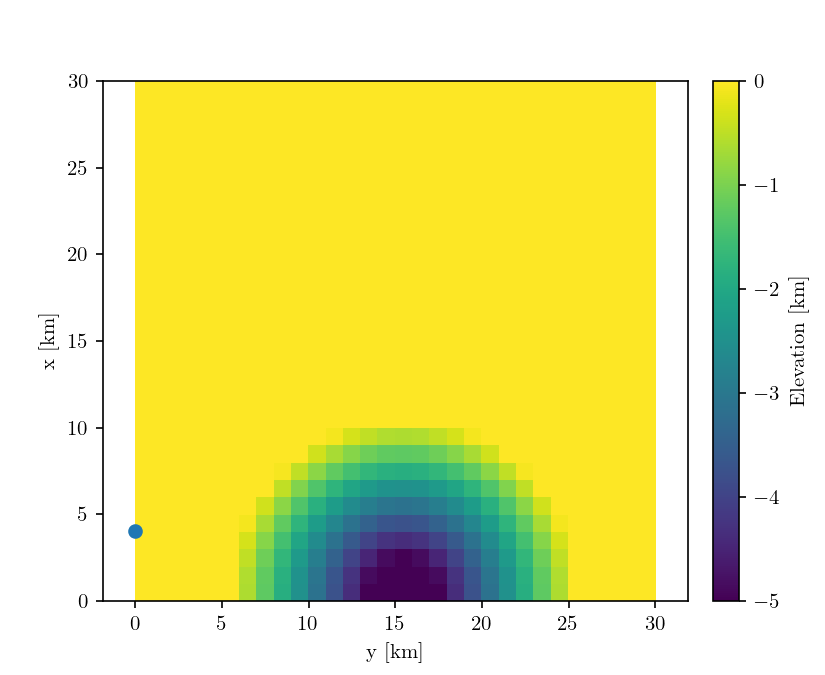

In [12]:
# rover
# assume the user is at the Poincare crater (in rad)
lat_user = np.deg2rad(-59.12448)
lon_user = np.deg2rad(161.05104)
# can initialize the rover with the desired initial location
rover = rover_class.Rover_Agent([lat_user, lon_user])
# TODO: need to make the state actually the rover state
rover_state = rover.rover_loc

N_t = 100          # number of time steps

# create a grid (specify number of cells and cell resolution)
grid_env = grid_world.GridWorld(30, 1, N_t, rover.rover_loc, 0.0, 0.0)
resolution = 1
# let's add some craters (if you do not specify location, they will be randomly placed)
# Set the grid
# crater = grid_env.create_crater(20, 1, (15, 18))
# grid_env.add_crater(crater, slope_factor=0.6)

# crater = grid_env.create_crater(10, 2, (35, 30))
# grid_env.add_crater(crater, slope_factor=0.2)

# crater = grid_env.create_crater(4, 0.75, (22, 15))
# grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(10, 5, (0, 15))
grid_env.add_crater(crater, slope_factor=0.2)



# crater = grid_env.create_crater(10, 2.5, [20, 20])
# grid_env.add_crater(crater, slope_factor=0.5)

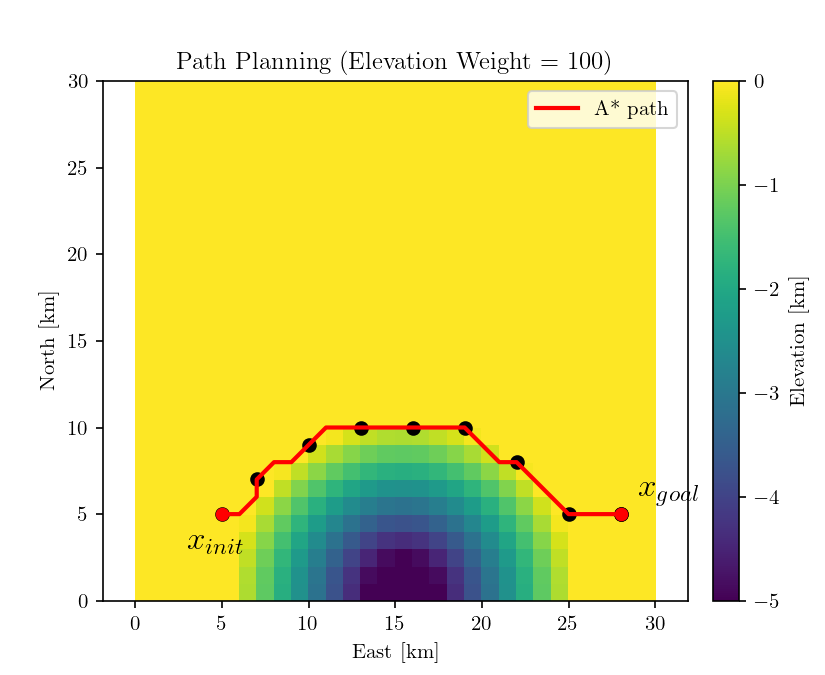

In [16]:
x_init = (5,5)
x_goal = (5,28)
# from AA274A --> needed lower bound tuple, upper bound tuple, initial state tuple, goal state tuple, occupancy as the grid, and resolution
# obstacles = [((6,7),(8,8)),((2,2),(4,3)),((2,5),(4,7)),((6,3),(8,5))]
# obstacles = [((0,7),(15,15)), ((25,22),(40,30))]
obstacles = None
elev_weight = 100
astar = AStarPlanner((0, 0), (grid_env.N, grid_env.N), x_init, x_goal, grid_env, resolution, True, obstacles, elev_weight)

if not astar.solve():
    print("No path found")
else:
    path_plan = astar.path
    plt.rcParams['figure.figsize'] = [5.5, 4.5]
    fig, ax = astar.plot_path()
    # astar.plot_tree()

ax.set_title(f'Path Planning (Elevation Weight = {elev_weight})')
ax.set_xlabel('East [km]')
ax.set_ylabel('North [km]')

waypoints = astar.get_waypoints(10)
# plot the downsampled path as scatter points
ax.plot(waypoints[:,1], waypoints[:,0], 'ko')

In [14]:
waypoints

array([[ 5,  5],
       [ 7,  7],
       [ 9, 10],
       [10, 13],
       [10, 16],
       [10, 19],
       [ 8, 22],
       [ 5, 25],
       [ 5, 28],
       [ 5, 28]])

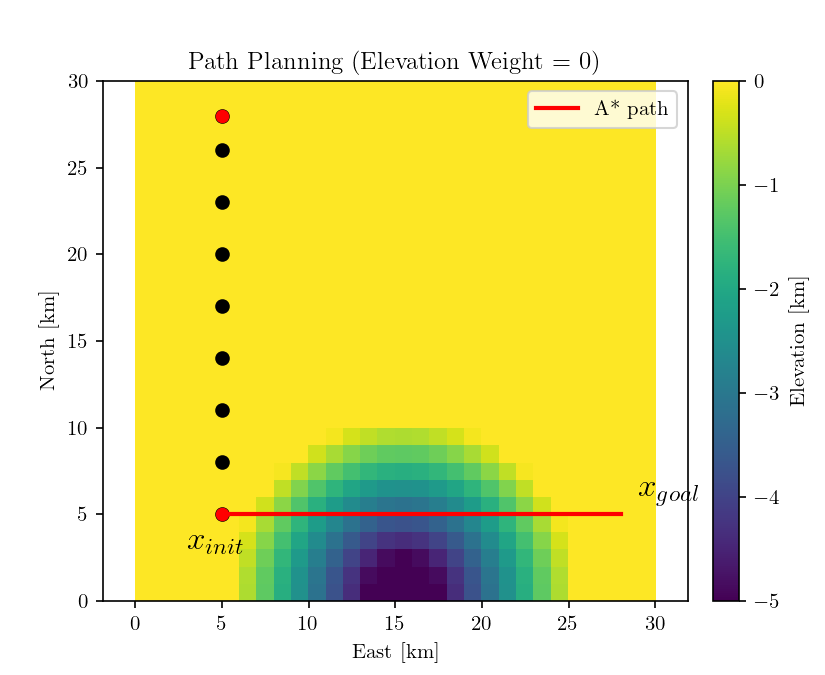

In [15]:
obstacles = None
elev_weight = 0
astar = AStarPlanner((0, 0), (grid_env.N, grid_env.N), x_init, x_goal, grid_env, resolution, True, obstacles, elev_weight)

if not astar.solve():
    print("No path found")
else:
    path_plan = astar.path
    plt.rcParams['figure.figsize'] = [5.5, 4.5]
    fig, ax = astar.plot_path()
    # astar.plot_tree()

ax.set_title(f'Path Planning (Elevation Weight = {elev_weight})')
ax.set_xlabel('East [km]')
ax.set_ylabel('North [km]')

waypoints = astar.get_waypoints(10)
# plot the downsampled path as scatter points
ax.plot(waypoints[:,0], waypoints[:,1], 'ko')